# Hands-On Project: Stellar Luminosity

## 1. Establishing environment

In [83]:
# Required libraries
%pip install numpy matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [84]:
import sys
import numpy as np 
import matplotlib.pyplot as plt

# Libraries' versions
print("Python version:", sys.version)
print("NumPy version:", np.__version__)
print("Matplotlib version:", plt.matplotlib.__version__)

Python version: 3.14.4 (tags/v3.14.4:23116f9, Apr  7 2026, 14:10:54) [MSC v.1944 64 bit (AMD64)]
NumPy version: 2.5.1
Matplotlib version: 3.11.1



As we are using NumPy library, then we are going to load the dataset as NumPy arrays:

In [85]:
mass = np.array([0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 2.2, 2.4])
luminosity = np.array([0.15, 0.35, 1.00, 2.30, 4.10, 7.00, 11.2, 17.5, 25.0, 35.0])

# Shapes of the arrays
print("Mass shape:", mass.shape)
print("Luminosity shape:", luminosity.shape)

# Ranges of the variables
print("Mass range:", mass.min(), "to", mass.max())
print("Luminosity range:", luminosity.min(), "to", luminosity.max())

Mass shape: (10,)
Luminosity shape: (10,)
Mass range: 0.6 to 2.4
Luminosity range: 0.15 to 35.0


___

## 2. Exploring before modeling

We are going to plot stellar mass against luminosity

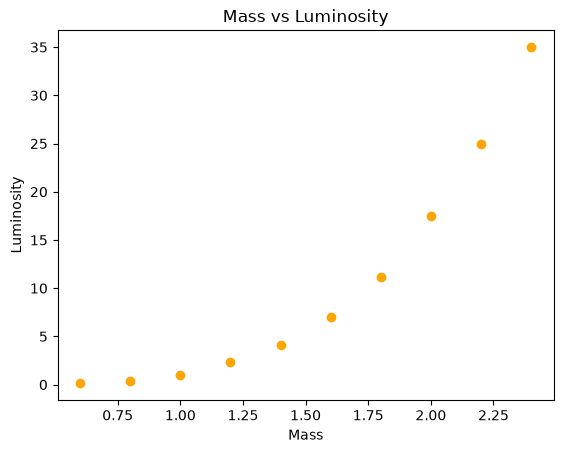

In [86]:
# First we create a new empty figure
plt.figure()

# Now we plot the data points
plt.scatter(mass, luminosity, color="orange")

# Then, we add labels and a title
plt.xlabel("Mass")
plt.ylabel("Luminosity")
plt.title("Mass vs Luminosity")

# Finally, we show the plot
plt.show()

### Describing the observed relation

The relationship between stellar mass and luminosity appears to be nonlinear. It's clear to see that as the stellar mass increases, the luminosity increases at a much faster rate, suggesting an upward-curving trend rather than a straight line.

A straight line does not appear to be adequate because it cannot fully capture the curved pattern. It would likely overestimate the luminosity of some stars and underestimate it for others, especially near the beginning and the end of the observed range. These systematic errors suggest that a nonlinear model may provide a better fit.

___

## 3. Implementing the learning algorithm

We'll use the model:

$$
f_{w,b}(x^{(i)}) = w x^{(i)} + b
$$

where:
 - $w$ is the slope,
 - $b$ the intercept.

In [87]:
def predict(X, w, b):
    return X @ w + b

We define the **mean squared error** as the cost function, just as it was made in class:

$$
J(w,b) = \frac{1}{2m} \sum_{i=1}^{m} \big( f_{w,b}(x^{(i)}) - y^{(i)} \big)^2
$$



In [88]:
def compute_cost(X, y, w, b):
    m = X.shape[0]

    errors = predict(X, w, b) - y
    cost = np.sum(errors**2) / (2*m) # Is it possible to use predict()?
    return cost

We use **gradient descent** with the update rules:

$$
\frac{\partial J}{\partial w} = \frac{1}{m} \sum_{i=1}^{m} \big( f_{w,b}(x^{(i)}) - y^{(i)} \big) x^{(i)}, \quad
\frac{\partial J}{\partial b} = \frac{1}{m} \sum_{i=1}^{m} \big( f_{w,b}(x^{(i)}) - y^{(i)} \big)
$$

Update:

$$
w := w - \alpha \frac{\partial J}{\partial w}, \quad
b := b - \alpha \frac{\partial J}{\partial b}
$$

In [89]:
def compute_gradients(X,y,w,b):
    m = X.shape[0]

    errors = predict(X, w, b) - y

    # Derivative of the cost function with respect to w
    df_dw = (X.T @ errors) / m

    # Derivative of the cost function with respect to b
    df_db = np.sum(errors) / m

    return df_dw, df_db

Now, let's implement the gradient descent loop:

In [90]:
def gradient_descent(X, y, w_init, b_init, alpha, num_iterations):
    w = w_init
    b = b_init
    history = []

    for i in range(num_iterations):
        # Compute gradients
        df_dw, df_db = compute_gradients(X, y, w, b)

        # Update parameters
        w = w - alpha * df_dw
        b = b - alpha * df_db

        # Save the cost
        cost = compute_cost(X, y, w, b)
        history.append((i, cost))

        # We are going to print the cost every 100 iterations
        if i % max(1, num_iterations // 10) == 0:
            print(
                f"Iteration {i:4d}: "
                f"w = {np.round(w, 4)}, "
                f"b = {b:7.4f}, "
                f"cost = {cost:8.4f}"
            )

    return w, b, history

We can see that this functions support design matrices thanks with one or more features thanks to NumPy library

___
## 4. Training a linear model

It is time to initialize the paramenters and choose a learning rate and a number of iterations.

For linear regression, gradient descent usually converges to the same solution regardless of the starting point, because the cost function is convex. Therefore, we will use the simplest initialization by setting both parameters to zero.

We will also choose a reasonable learning rate: not too large and not too small. Finally, we will select a number of iterations that is large enough for the algorithm to converge.

In [91]:
# Design matrix for the linear model
X_linear = mass.reshape(-1, 1) # Reshape to a column vector

# Is that what the workshop meant? X_linear = [mass]

w = np.zeros(X_linear.shape[1])
b = 0.0
alpha = 0.01
num_iterations = 10000

Now, we are going to train the model.

In [92]:
w_learned, b_learned, cost_history = gradient_descent(X_linear, luminosity, w, b, alpha, num_iterations)

print("Learned parameters:")
print("w = ", w_learned)
print("b = ", b_learned)

Iteration    0: w = [0.2152], b =  0.1036, cost = 112.0896
Iteration 1000: w = [13.3693], b = -8.9470, cost =  13.8142
Iteration 2000: w = [16.284], b = -13.7764, cost =  10.3996
Iteration 3000: w = [17.4143], b = -15.6491, cost =   9.8860
Iteration 4000: w = [17.8526], b = -16.3754, cost =   9.8088
Iteration 5000: w = [18.0226], b = -16.6571, cost =   9.7972
Iteration 6000: w = [18.0885], b = -16.7663, cost =   9.7955
Iteration 7000: w = [18.1141], b = -16.8086, cost =   9.7952
Iteration 8000: w = [18.124], b = -16.8251, cost =   9.7952
Iteration 9000: w = [18.1279], b = -16.8314, cost =   9.7951
Learned parameters:
w =  [18.12935781]
b =  -16.833888424078236


To make better observations we are going to plot some model training behaviors

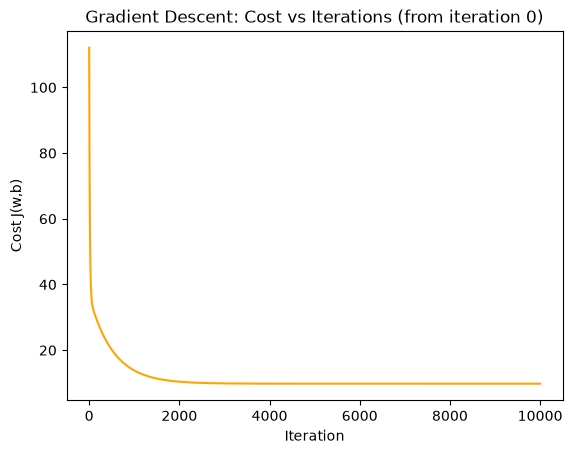

In [93]:
iterations = [it for it, c in cost_history]
cost = [c for it, c in cost_history]

# We can change this to zoom into the cost curve
start_iteration = 0

# Find the first index where the iteration is greater than or equal to start_iteration
start_index = 0
for i in range(len(iterations)):
    if iterations[i] >= start_iteration:
        start_index = i
        break

fig , ax = plt.subplots()
ax.plot(iterations[start_index:], cost[start_index:], color = "orange")
ax.set_xlabel("Iteration")
ax.set_ylabel("Cost J(w,b)")
ax.set_title(f"Gradient Descent: Cost vs Iterations (from iteration {iterations[start_iteration]})") # The iteration number is different in the workshop 3

# This keeps the labels as the actual cost values instead of scientific notation
ax.ticklabel_format(axis='y', style='plain', useOffset=False)

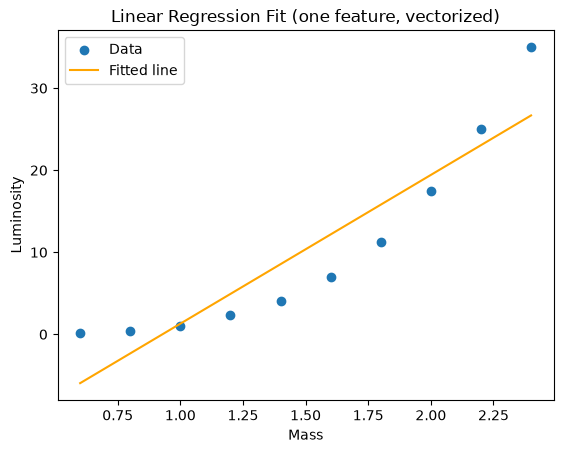

In [94]:
plt.figure()
plt.scatter(mass, luminosity, label="Data")

y_pred_linear = predict(X_linear, w_learned, b_learned)

plt.plot(mass, y_pred_linear, color="orange", label="Fitted line")
plt.xlabel("Mass")
plt.ylabel("Luminosity")
plt.title("Linear Regression Fit (one feature, vectorized)")
plt.legend()
plt.show()

In [95]:
# Final parameter and cost values
print(f"Final parameters: w = {w_learned[0]}, b = {b_learned}")
print(f"Final cost: {cost_history[-1][1]}")

Final parameters: w = 18.129357806016017, b = -16.833888424078236
Final cost: 9.79514864326178


### Convergence and systematic errors

The cost decreases consistently during gradient descent and becomes
progressively flatter, indicating that the algorithm is approaching
convergence.

However, the fitted straight line does not follow the observations
equally well across the entire mass range. It systematically
overestimates luminosity in some regions and underestimates it in
others, especially as the relationship becomes more curved at higher
masses. This suggests that the limitation comes from the linear form
of the model rather than from the optimization process.


___
## 5. Training a polynomial model

Now, we are going to create the representation

$$
\textit{X\_polinomial} = [mass, mass^{2}]
$$

In [96]:
mass_sqr = [m**2 for m in mass]

Reusing the functions develop above we will train the polynomial model

In [97]:
# Design matrix for the polynomial model
X_polynomial = np.column_stack((mass, mass_sqr))

# The parameters initialization
w_poly = np.zeros(X_polynomial.shape[1])
b_poly = 0.0

# Training the polynomial model
alpha_poly = 0.0001
iterations_poly = 10000

w_learned_poly, b_learned_poly, cost_history_poly = gradient_descent(X_polynomial, luminosity, w_poly, b_poly, alpha_poly, iterations_poly)


Iteration    0: w = [0.0022 0.0046], b =  0.0010, cost = 117.4288
Iteration 1000: w = [1.1545 2.6351], b =  0.4904, cost =  21.2255
Iteration 2000: w = [1.3824 3.4438], b =  0.4776, cost =  13.3099
Iteration 3000: w = [1.3593 3.7494], b =  0.3324, cost =  12.0958
Iteration 4000: w = [1.27   3.9139], b =  0.1562, cost =  11.4302
Iteration 5000: w = [1.1652 4.0369], b = -0.0232, cost =  10.8465
Iteration 6000: w = [1.0586 4.1459], b = -0.1986, cost =  10.3064
Iteration 7000: w = [0.9539 4.2484], b = -0.3681, cost =   9.8045
Iteration 8000: w = [0.8521 4.3466], b = -0.5313, cost =   9.3379
Iteration 9000: w = [0.7534 4.4412], b = -0.6884, cost =   8.9041


Let's see some training model behaviors in a graph.

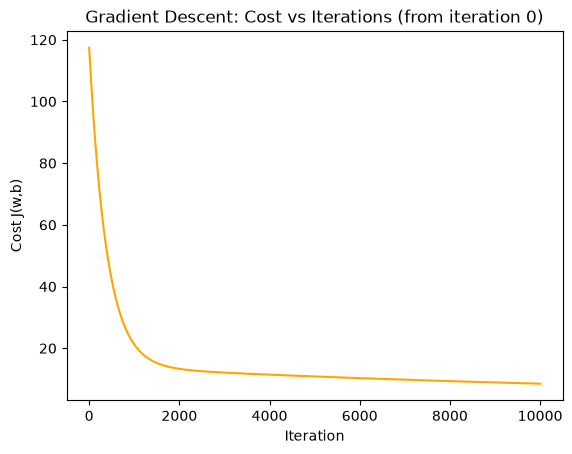

In [98]:
iterations = [it for it, c in cost_history_poly]
cost = [c for it, c in cost_history_poly]

start_iteration_poly = 0

start_index_poly = 0
for i in range(len(iterations)):
    if iterations[i] >= start_iteration_poly:
        start_index_poly = i
        break

fig, ax = plt.subplots()
ax.plot(iterations[start_index_poly:], cost[start_index_poly:], color = "orange")
ax.set_xlabel("Iteration")
ax.set_ylabel("Cost J(w,b)")
ax.set_title(f"Gradient Descent: Cost vs Iterations (from iteration {iterations[start_iteration]})")

ax.ticklabel_format(axis='y', style='plain', useOffset=False)

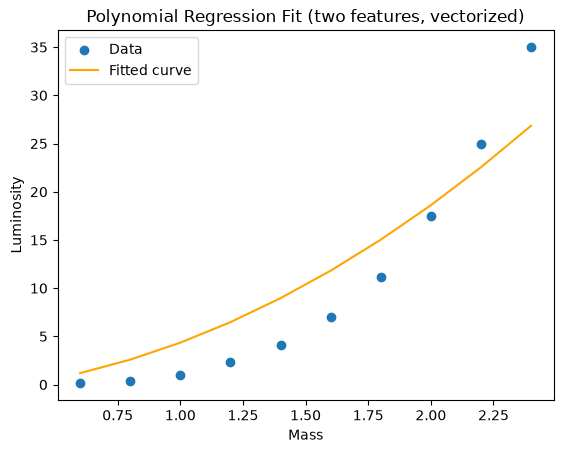

In [99]:
plt.figure()
plt.scatter(mass, luminosity, label="Data")

y_pred_poly = predict(X_polynomial, w_learned_poly, b_learned_poly)

plt.plot(mass, y_pred_poly, color="orange", label="Fitted curve")
plt.xlabel("Mass")
plt.ylabel("Luminosity")
plt.title("Polynomial Regression Fit (two features, vectorized)")
plt.legend()
plt.show()

### What changed in the model and what remained unchanged?

In the polynomial model, the main change is the input representation. Instead of using only stellar mass as one feature, the design matrix now includes both mass and mass squared. Therefore, the model changes from a straight-line relationship to a quadratic relationship:

$$
\hat{y} = w_{1}x + w_{2}x^{2} + b
$$

This also means that the model now has two weights instead of one, because each feature has its own coefficient. The squared term gives the model the ability to represent curvature in the relationship between stellar mass and luminosity.

What remains unchanged is the general learning procedure. The same target variable, luminosity, is used; predictions are still computed from the design matrix, weights, and bias; the same cost function is minimized; and gradient descent is still used to update the parameters. The bias remains a single scalar value. In other words, the optimization method remains the same, while the feature representation and therefore the shape of the fitted model change.

___
## Comparing the models

According to each model's information, we are going to make a comparison between them to make an accurate conclusion of which model represents the observed range better and why.

In [100]:
# Comparing final costs of both models
final_cost_linear = cost_history[-1][1]
final_cost_poly = cost_history_poly[-1][1]

print(f"Final cost - Linear model: {final_cost_linear}")
print(f"Final cost - Polynomial model: {final_cost_poly}")

Final cost - Linear model: 9.79514864326178
Final cost - Polynomial model: 8.501148211306232


The polynomial model achieved a lower final training cost than the linear model. This indicates that, for the observed data used during training, the polynomial model produces predictions that are closer to the observed luminosity values according to the cost function.

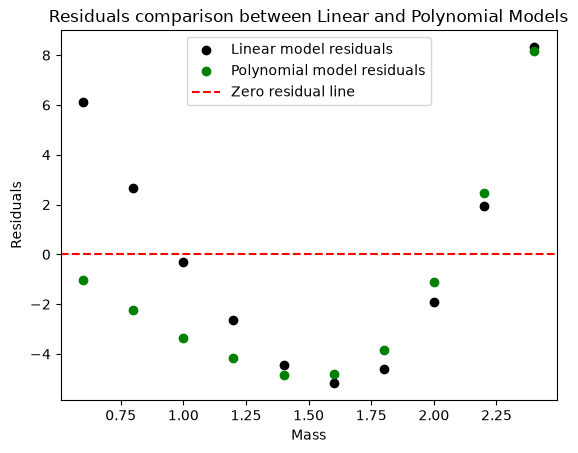

In [101]:
# Inspecting the residuals of both models
residuals_linear = luminosity - y_pred_linear
residuals_poly = luminosity - y_pred_poly

# Ploting the residuals for both models
plt.figure();

plt.scatter(mass, residuals_linear, color="black", label="Linear model residuals")
plt.scatter(mass, residuals_poly, color="green", label="Polynomial model residuals")

plt.axhline(0, color="red", linestyle="--", label="Zero residual line")

plt.xlabel("Mass")
plt.ylabel("Residuals")
plt.title("Residuals comparison between Linear and Polynomial Models")
plt.legend()
plt.show()



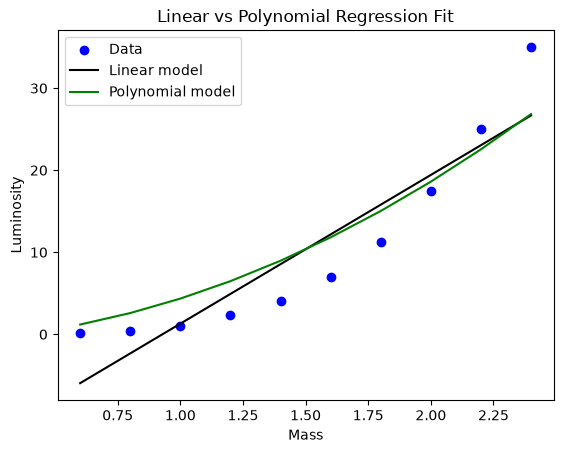

In [102]:
# Both fitted models with the observations

plt.figure()

plt.scatter(mass, luminosity, color="blue", label="Data",)
plt.plot(mass, y_pred_linear, color="black", label="Linear model")
plt.plot(mass, y_pred_poly, color="green", label="Polynomial model")

plt.xlabel("Mass")
plt.ylabel("Luminosity")
plt.title("Linear vs Polynomial Regression Fit")
plt.legend()
plt.show()


### Which model represents the observed range better and why?
Over the observed mass range, the polynomial model represents the data better than the linear model. Its fitted curve follows the increasing curvature of the observations more closely, while the linear model is constrained to a straight line and therefore systematically misses parts of the relationship. The polynomial model also obtains a lower training cost and generally smaller residuals. Together, these results indicate that the polynomial representation provides a better description of the observed data.

## Testing the boundary of the evidence

We are going to generate predictions from both models for:

- $mass = 1.3$, inside the observed range.
- $mass = 5.0$, far outside the observed range.

In [ ]:
test_masses = np.array([1.3, 5.0])

X_test_linear = test_masses.reshape(-1, 1)
# Predicting luminosity for the test masses using linear model
y_test_linear = predict(X_test_linear, w_learned, b_learned)

X_test_polynomial = np.column_stack((test_masses, test_masses**2))
# Predicting luminosity for the test masses using polynomial model
y_test_poly = predict(X_test_polynomial, w_learned_poly, b_learned_poly)

# Displaying the predictions
for mass_value, linear_pred, poly_pred in zip(
    test_masses,
    y_test_linear,
    y_test_poly
):
    print(f"Mass = {mass_value:.1f}")
    print(f"Linear prediction: {linear_pred:.4f}")
    print(f"Polynomial prediction: {poly_pred:.4f}")
    print()


Mass = 1.3
Linear prediction: 6.7343
Polynomial prediction: 7.6757

Mass = 5.0
Linear prediction: 73.8129
Polynomial prediction: 115.7619

[18.12935781]
-16.833888424078236
[0.65768778 4.53250765]
-0.8392650106764231


The prediction for mass 1.3 is better supported by the available evidence because it is an interpolation within the observed range. In contrast, mass 5.0 requires extrapolation far beyond the available observations. The large difference between the linear and polynomial predictions at 5.0 illustrates how models that may fit the observed data reasonably well can behave very differently outside that range. Therefore, the dataset does not provide sufficient evidence to strongly trust either prediction at mass 5.0.